# Supermarket Sales Analysis

**Author:** Divyanshi Shaw  
**Degree:** Master of Business Analytics, Deakin University  
**Tools:** Python · Pandas · Matplotlib · Seaborn · SQL (SQLite)  
**Dataset:** Supermarket Sales — 1,000 transactions across 3 branches (Jan–Mar 2019)  
**Source:** [Kaggle — Supermarket Sales Dataset](https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales)

---

## Project Overview

This project analyses retail transaction data from a supermarket chain operating across three branches (A, B, C). The goal is to surface actionable business insights around revenue performance, customer behaviour, and product profitability — combining Python visualisation with SQL-based querying to demonstrate an end-to-end analytics workflow.

## Business Questions
1. Which branch generates the most revenue and highest customer satisfaction?
2. Which product lines are the most and least profitable?
3. Do member customers spend more than non-members?
4. What payment methods do customers prefer?
5. How does revenue trend across the three-month period?

## Dataset Features
| Column | Description |
|---|---|
| Branch | Store location (A, B, C) |
| Product line | Category of goods purchased |
| Total | Transaction value (USD incl. tax) |
| Customer type | Member or Normal |
| Payment | Cash, Credit card, or Ewallet |
| Rating | Customer satisfaction (1–10) |
| Date | Transaction date (Jan–Mar 2019) |


## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
COLORS = ["#5B8DB8", "#6AAB6E", "#E07B54"]

df = pd.read_excel("data/supermarket_sales.xlsx")
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total revenue: ${df['Total'].sum():,.2f}")
df.head()

(1000, 17)
    Invoice ID Branch      City Customer type  Gender            Product line  \
0  692-92-5582      B  Mandalay        Member  Female      Food_and_beverages   
1  351-62-0822      B  Mandalay        Member  Female     Fashion_accessories   
2  529-56-3974      B  Mandalay        Member    Male  Electronic_accessories   
3  299-46-1805      B  Mandalay        Member  Female       Sports_and_travel   
4  319-50-3348      B  Mandalay        Normal  Female      Home_and_lifestyle   

   Unit price  Quantity  Tax 5%    Total                 Date      Time  \
0       54.84         3   8.226  172.746            2/20/2019  13:27:00   
1       14.48         4   2.896   60.816  2019-06-02 00:00:00  18:07:00   
2       25.51         4   5.102  107.142  2019-09-03 00:00:00  17:03:00   
3       93.72         6  28.116  590.436            1/15/2019  16:19:00   
4       40.30         2   4.030   84.630  2019-11-03 00:00:00  15:30:00   

       Payment    cogs  gross margin percentage  gr

## 2. Visual Dashboard — 6-Panel Overview

A single-figure dashboard covering all five business questions simultaneously, designed for an executive audience.


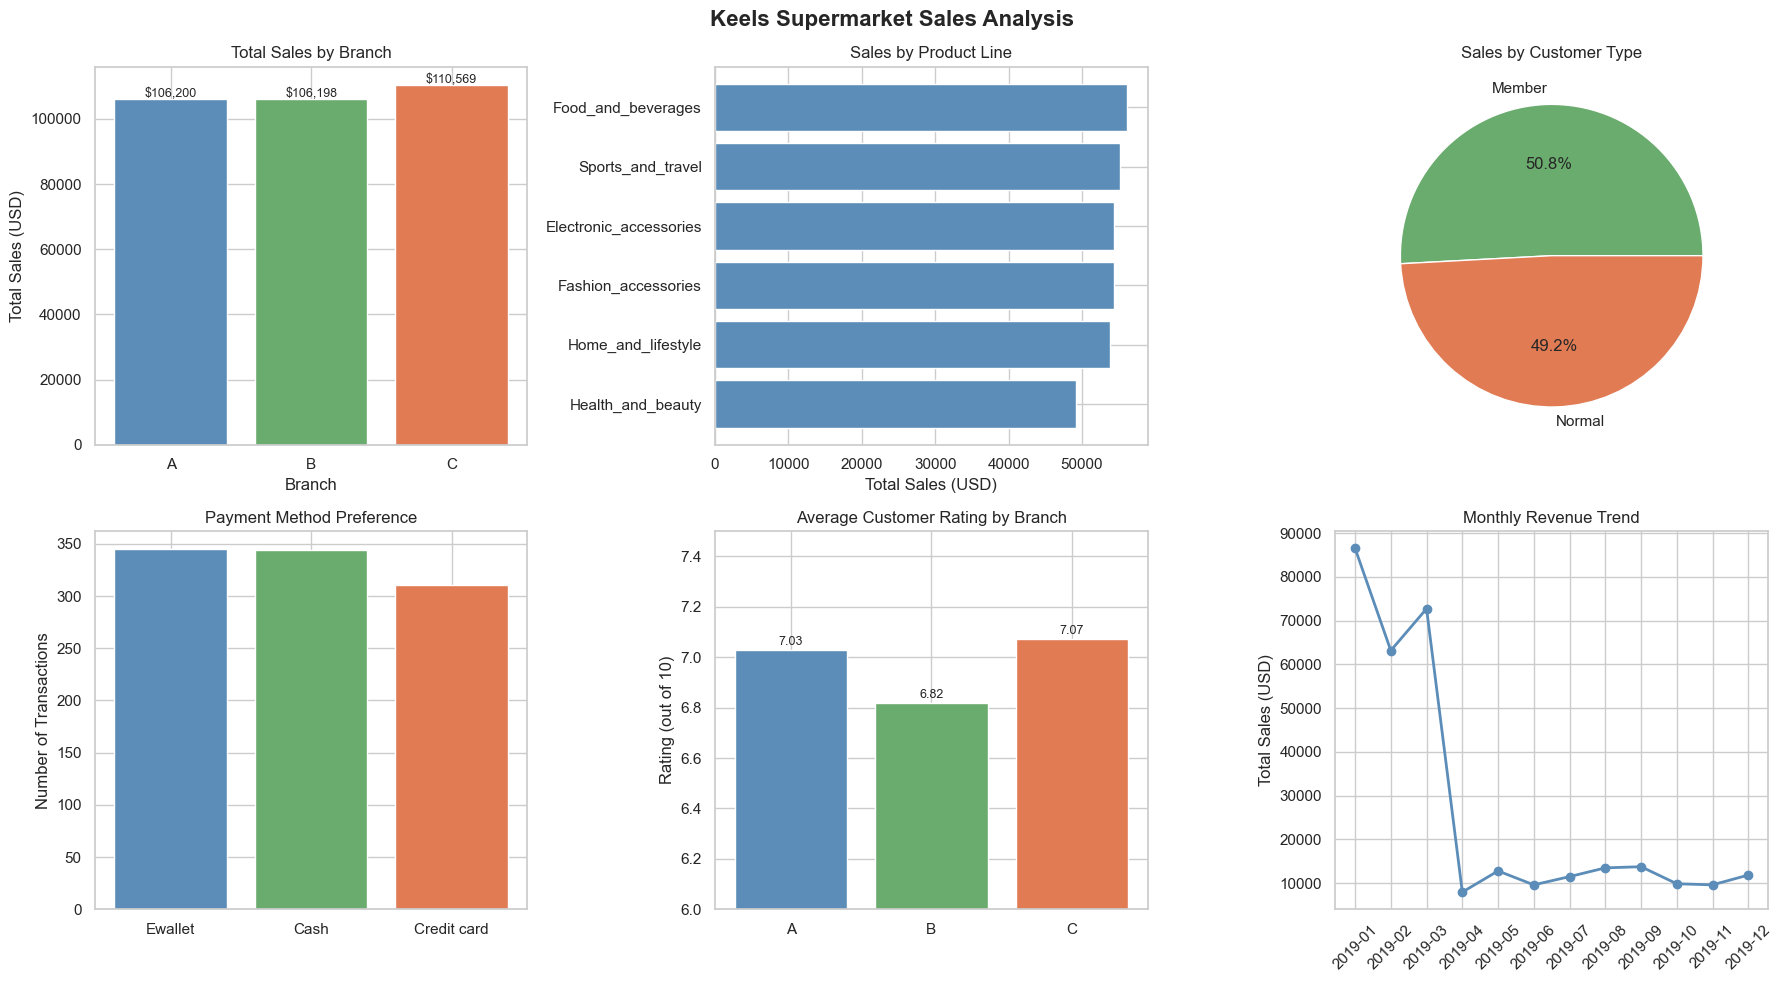

Done!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Keels Supermarket Sales Analysis", fontsize=16, fontweight="bold")

# 1. Sales by Branch
branch_sales = df.groupby("Branch")["Total"].sum()
axes[0,0].bar(branch_sales.index, branch_sales.values, color=["#5B8DB8","#6AAB6E","#E07B54"])
axes[0,0].set_title("Total Sales by Branch")
axes[0,0].set_xlabel("Branch")
axes[0,0].set_ylabel("Total Sales (USD)")
for i, v in enumerate(branch_sales.values):
    axes[0,0].text(i, v + 500, f"${v:,.0f}", ha="center", fontsize=9)

# 2. Sales by Product Line
product_sales = df.groupby("Product line")["Total"].sum().sort_values()
axes[0,1].barh(product_sales.index, product_sales.values, color="#5B8DB8")
axes[0,1].set_title("Sales by Product Line")
axes[0,1].set_xlabel("Total Sales (USD)")

# 3. Customer Type
cust = df.groupby("Customer type")["Total"].sum()
axes[0,2].pie(cust.values, labels=cust.index, autopct="%1.1f%%",
              colors=["#6AAB6E","#E07B54"])
axes[0,2].set_title("Sales by Customer Type")

# 4. Payment Method
pay = df["Payment"].value_counts()
axes[1,0].bar(pay.index, pay.values, color=["#5B8DB8","#6AAB6E","#E07B54"])
axes[1,0].set_title("Payment Method Preference")
axes[1,0].set_ylabel("Number of Transactions")

# 5. Average Rating by Branch
rating = df.groupby("Branch")["Rating"].mean()
axes[1,1].bar(rating.index, rating.values, color=["#5B8DB8","#6AAB6E","#E07B54"])
axes[1,1].set_title("Average Customer Rating by Branch")
axes[1,1].set_ylabel("Rating (out of 10)")
axes[1,1].set_ylim(6, 7.5)
for i, v in enumerate(rating.values):
    axes[1,1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

# 6. Monthly Revenue Trend
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")
monthly = df.groupby("Month")["Total"].sum()
axes[1,2].plot(monthly.index.astype(str), monthly.values, 
               marker="o", color="#5B8DB8", linewidth=2)
axes[1,2].set_title("Monthly Revenue Trend")
axes[1,2].set_ylabel("Total Sales (USD)")
axes[1,2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(r"C:\Users\Divyanshi Shaw\supermarket_dashboard.png", dpi=150)
plt.show()
print("Done!")

## 3. SQL Analysis — Deep Dive Queries

Loading the dataframe into an in-memory SQLite database to run structured queries — demonstrating SQL alongside Python in a single analytical workflow. This mirrors how a data analyst would combine a BI tool with a SQL-backed data warehouse.


In [ ]:
import sqlite3

# Fix - convert Month back to string before loading to SQL
df_sql = df.copy()
df_sql["Month"] = df_sql["Month"].astype(str)
df_sql["Date"] = df_sql["Date"].astype(str)
df_sql["Time"] = df_sql["Time"].astype(str)

conn = sqlite3.connect(":memory:")
df_sql.to_sql("sales", conn, index=False, if_exists="replace")

print("=== Revenue by Branch ===")
q1 = pd.read_sql("SELECT Branch, ROUND(SUM(Total),2) as Total_Revenue, COUNT(*) as Transactions FROM sales GROUP BY Branch ORDER BY Total_Revenue DESC", conn)
print(q1)

print("\n=== Best Product Lines ===")
q2 = pd.read_sql("SELECT [Product line], ROUND(SUM(Total),2) as Revenue, ROUND(AVG(Rating),2) as Avg_Rating FROM sales GROUP BY [Product line] ORDER BY Revenue DESC", conn)
print(q2)

print("\n=== Member vs Normal ===")
q3 = pd.read_sql("SELECT [Customer type], ROUND(SUM(Total),2) as Revenue, ROUND(AVG(Total),2) as Avg_Transaction FROM sales GROUP BY [Customer type]", conn)
print(q3)

print("\n=== Branch Ratings ===")
q4 = pd.read_sql("SELECT Branch, ROUND(AVG(Rating),2) as Avg_Rating, ROUND(AVG(Total),2) as Avg_Sale FROM sales GROUP BY Branch ORDER BY Avg_Rating DESC", conn)
print(q4)

conn.close()
print("\nSQL done!")

=== Revenue by Branch ===
  Branch  Total_Revenue  Transactions
0      C      110568.71           328
1      A      106200.37           340
2      B      106197.67           332

=== Best Product Lines ===
             Product line   Revenue  Avg_Rating
0      Food_and_beverages  56144.84        7.11
1       Sports_and_travel  55122.83        6.92
2  Electronic_accessories  54337.53        6.92
3     Fashion_accessories  54305.89        7.03
4      Home_and_lifestyle  53861.91        6.84
5       Health_and_beauty  49193.74        7.00

=== Member vs Normal ===
  Customer type    Revenue  Avg_Transaction
0        Member  164223.44           327.79
1        Normal  158743.30           318.12

=== Branch Ratings ===
  Branch  Avg_Rating  Avg_Sale
0      C        7.07    337.10
1      A        7.03    312.35
2      B        6.82    319.87

SQL done!


## 4. Key Business Findings

| Question | Finding | Recommendation |
|---|---|---|
| Best branch by revenue | Branch C leads ($110,569) but all three within 3% | System is well-balanced — no single dominant location |
| Best product line | Food & Beverages and Sports & Travel top revenue | Prioritise for promotions and shelf space |
| Member vs Normal | Revenue split nearly 50/50; similar avg basket size | Membership drives volume but not higher spend per visit |
| Payment preference | Ewallet, cash, and credit card evenly distributed | Maintain all three options — no dominant preference |
| Monthly trend | Revenue dips in February before recovering in March | Mid-quarter promotions could smooth the February dip |

---
*Analysis by Divyanshi Shaw — MBusAnalytics candidate, Deakin University*  
*Dataset: Kaggle Supermarket Sales (public domain)*
